# Creating Spectrograms for Each ROI and Each Condition

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
#-----imports-----#
import numpy as np
from matplotlib import pyplot as plt

from mne import Epochs, create_info
from mne.io import RawArray
from mne.time_frequency import AverageTFRArray, EpochsTFRArray, tfr_array_morlet

import os
import matplotlib.pyplot as plt

In [3]:
import sys 
from pathlib import Path

# get project root 
project_root = Path("/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis")
sys.path.append(str(project_root))



### Load previous functions 

First pre-process data, then align tics from Excel and EEG data, then exctract pre tic epochs, based on that data make for each phase time-frequency analysis 

In [4]:
from _02_Movidoc_tictrack_prepro_TTL_extraction_patients import (
    load_data,
    extract_stimuli,
    preprocess_data, 
    apply_rest_reference,
    recalibrate_from_first_event,
    collect_ttl_with_phases
)

In [5]:
from _03_Movidoc_tictrack_tic_extraction_patients import extract_tics_from_excel

In [6]:
from _04_Movidoc_full_pipeline_analysis_patients import (
    assign_phase_to_tics,
    extract_eeg_phase_times_from_ttl,
    realign_excel_to_eeg,
    build_merged_ttl_tics,
    run_full_pipeline_for_patient,
    shift_urges_times,
    extract_random_epochs_in_phase,
    analyse_merged_ttl_tics,
    extract_pre_tic_epochs,
)

>>> LE SCRIPT A BIEN ÉTÉ LANCÉ


## Load the data 

For now one participant

In [7]:
# Base directory for this project
base_dir = "/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis"
patient_files_dir = os.path.join(base_dir, "PATIENT FILES")
eeg_dir = os.path.join(patient_files_dir, "EEG PATIENT FILES")
excel_dir = os.path.join(patient_files_dir, "EXCEL PATIENT FILES")



In [8]:
# Define patient configurations
patients = [
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000010.vhdr"),
        "excel": os.path.join(excel_dir, "DS26_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [13.728, 50.028, 190.080, 349.272, 980.727, 1277.991]
    },
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack_BB28-bis.vhdr"), #BB28
        "excel": os.path.join(excel_dir, "BB28_annotations_binary-table_cutted.xlsx"),
        "fps": 25,
        "min_absence_frames": 25,
        "excel_phase_times": [9.840, 27.320, 156.880, 302.600, 929.960, 991.760]
    },
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000013.vhdr"), # BC29
        "excel": os.path.join(excel_dir, "BC29_annotations_binary-table_cutted_Lizbeth.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [17.391, 65.670, 201.597, 358.215, 1088.670, 1204.038]
    },
    {
        "montage": "standard_1005", # montage with 64 electrodes (from MM30 : always 64 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000030.vhdr"), # MM30
        "excel": os.path.join(excel_dir, "MM30_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [6.633, 68.277, 196.581, 323.994, 931.194, 995.049]
    },
    {
        "montage": "standard_1005", # montage with 64 electrodes (from MM30 : always 64 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000031.vhdr"), # SC31
        "excel": os.path.join(excel_dir, "SC31_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [12.243, 62.040, 191.664, 345.972, 970.200, 1074.546]
    }
]

## Run full pipeline and extract pre-tic epochs 

In [9]:
def full_pipeline_extract_pre_tic_epochs(patient, phase,nb_random_epochs):
    # Run the full pipeline for the patient
    print('Processing start')
    results = run_full_pipeline_for_patient(
        vhdr_path = patient["vhdr"],
        excel_path = patient["excel"],
        fps = patient["fps"],
        min_absence_frames = patient["min_absence_frames"],
        montage_name = patient["montage"],
        excel_phase_times = patient["excel_phase_times"],
        )
    print('Processing done')
    phase_map = {
        "spontaneous_phase": ("start_spont", "end_spont"),
        "imitated_phase": ("start_imit", "end_imit"),
        "suppressed_phase": ("start_ret", "end_ret"),
        "closed_eyes_phase": ("start_close", "end_close"),
        "open_eyes_phase": ("start_open", "end_open"),
        }
    filter_dict = {
        'D': 21, 
        'F': 22,
        'S': 23,
        'T': 24,
        'right': 25,
        'start_spont': 9,
        'end_spont': 10,
        'start_imit': 11,
        'end_imit': 12,
        'start_ret': 13,
        'end_ret': 14,
        'start_close' : 5,
        'end_close' : 6,
        'start_open' : 7,
        'end_open' : 8,
        }
    phase_start_key, phase_end_key = phase_map[phase]

    #set the phase boundary 
    start_ttl_number = filter_dict[phase_start_key]
    end_ttl_number   = filter_dict[phase_end_key]

  
    ttl_info = results["ttl"]  

    start_time = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == start_ttl_number)
    end_time   = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == end_ttl_number)


    # Urges list 
    urges_list = {}
    print('Analysing merged ttl tics')
    analysis_list_patient = analyse_merged_ttl_tics(
        merged_ttl_tics=results["merged_ttl_tics"],
        phase_start_key = phase_start_key, 
        phase_end_key = phase_end_key,
        )
    urges_list[f"list_urges_{results['subject']}"] = analysis_list_patient
    print('Analysis done')

    # Shift urges to EEG time
    urges_list = urges_list[f"list_urges_{results['subject']}"]
    stim2_time = results["stim2_time_original"]

    print('Shifting urges times to EEG time')
    urges_times_EEG_patient = shift_urges_times(
        urges_list=urges_list,
        stim2_time=stim2_time,
        )
    print('Shifting done')

    # Extract pre-tic epochs
    print('Extracting pre-tic epochs')
    pre_tic_epochs = extract_pre_tic_epochs(
        raw_cropped =results["raw_cropped"],
        urge_times =urges_times_EEG_patient,
        pre_seconds=3.0, post_seconds=1.0
        )
    print('Pre-tic epochs extraction done')

    # Extract random epochs in the same phase
    print('Extracting random epochs in phase')
    random_epochs = extract_random_epochs_in_phase(
        raw_cropped=results["raw_cropped"],
        start_time=start_time,
        end_time=end_time,
        n_epochs=nb_random_epochs,
        epoch_duration=3,
        event_id=999,
        seed=42
        )
    print('Random epochs extraction done')
    
    return pre_tic_epochs, random_epochs

In [ ]:
#patient 1
pre_tic_epochs_p1_spont, random_epochs_p1_spont = full_pipeline_extract_pre_tic_epochs(patients[0], phase="spontaneous_phase", nb_random_epochs=50)
#patient 2
pre_tic_epochs_p2_spont, random_epochs_p2_spont = full_pipeline_extract_pre_tic_epochs(patients[1], phase="spontaneous_phase", nb_random_epochs=50)
#patient 3
pre_tic_epochs_p3_spont, random_epochs_p3_spont = full_pipeline_extract_pre_tic_epochs(patients[2], phase="spontaneous_phase", nb_random_epochs=50)
#patient 4
pre_tic_epochs_p4_spont, random_epochs_p4_spont = full_pipeline_extract_pre_tic_epochs(patients[3], phase="spontaneous_phase", nb_random_epochs=50)
#patient 5
pre_tic_epochs_p5_spont, random_epochs_p5_spont = full_pipeline_extract_pre_tic_epochs(patients[4], phase="spontaneous_phase", nb_random_epochs=50)


In [10]:
epochs_spont_patients = [
    pre_tic_epochs_p1_spont,
    pre_tic_epochs_p2_spont,
    pre_tic_epochs_p3_spont,
    pre_tic_epochs_p4_spont,
    pre_tic_epochs_p5_spont
]

patient_ids = ["DS26", "BB28", "BC29", "MM30", "SC31"]

NameError: name 'pre_tic_epochs_p1_spont' is not defined

### Plot raw pre-tic data 

In [ ]:
save_folder = "Raw pre-tic epoch data - MM30 (random)"
os.makedirs(save_folder, exist_ok=True)  

for i in range(len(random_epochs_p4_spont)):
    fig = random_epochs_p4_spont[i].plot(n_epochs = 1,scalings='auto', n_channels=32, title=f'Patient 4 - Pre-tic epoch {i+1} - Spontaneous phase')
    
    fig.savefig(os.path.join(save_folder, f'Patient4_pre_tic_epoch_{i+1}_spontaneous_phase.png'))


#### Plot raw pre-tic data for ROI

In [ ]:


channels_to_use_32 = ["Cz", "C3", "C4", "Pz", "Fp1", "Fp2"]
channels_to_use_64 = ["Cz", "FCz", "C3", "FC3", "CP3", "C4", "CP4", "FC4", "Pz", "CPz", "Fp1", "Fp2", "AF3", "AFz", "AF4"]

roi_lists_32 = {
    "midline_premotor": ["Cz"],
    "left_sensorimotor": ["C3"],
    "right_sensorimotor": ["C4"],
    "midline_posterior": ["Pz"],
    "midline_prefrontal": ["Fp1", "Fp2"]
}
roi_lists_64 = {
    "midline_premotor": ["Cz", "FCz"],
    "left_sensorimotor": ["C3", "FC3", "CP3"],
    "right_sensorimotor": ["C4", "CP4", "FC4"],
    "midline_posterior": ["Pz", "CPz"],
    "midline_prefrontal": ["Fp1", "Fp2", "AF3", "AFz", "AF4"]
}
# Choice of the ROI depending on the patient's montaget
if patients[3]["montage"] == "standard_1020":
    channels_to_use = channels_to_use_32
    roi_lists = roi_lists_32
elif patients[3]["montage"] == "standard_1005":
    channels_to_use = channels_to_use_64
    roi_lists = roi_lists_64
else:
    raise ValueError(f"Montage inconnu pour le patient {subject}: {patient['montage']}")



In [ ]:
epochs_roi = random_epochs_p4_spont.copy().pick(channels_to_use)
save_folder = "Raw pre-tic epoch data - MM30 (random) (selected ROIs)"
os.makedirs(save_folder, exist_ok=True)  
for epoch in range(len(epochs_roi)):
    fig = epochs_roi[epoch].plot(n_epochs = 1,scalings='auto', n_channels=len(channels_to_use), title=f'Patient 4 - Pre-tic epoch {epoch+1} - Spontaneous phase - Selected ROIs (random)')
    fig.savefig(os.path.join(save_folder, f'Patient4_pre_tic_epoch_{epoch+1}_spontaneous_phase_selected_ROIs (random).png'))
    

## Plot each channel seperately (for ROI) to identify incorrect channels 

In [ ]:
channels_to_use_32 = ["Cz", "C3", "C4", "Pz", "Fp1", "Fp2"]
channels_to_use_64 = ["Cz", "FCz", "C3", "FC3", "CP3", "C4", "CP4", "FC4", "Pz", "CPz", "Fp1", "Fp2", "AF3", "AFz", "AF4"]


patient = patients[3]  # Example: processing patient 4 (MM30)
root_folder= "Raw pre-tic epoch data - MM30 (all channels)"
os.makedirs(root_folder, exist_ok=True)

# Choose ROIs based on montage
if patient["montage"] == "standard_1020":
    channels_to_use = channels_to_use_32
elif patient["montage"] == "standard_1005":
    channels_to_use = channels_to_use_64
else:
    raise ValueError(f"Unknown montage for patient {pid}: {patient['montage']}")

for epoch in range(len(pre_tic_epochs_p4_spont)):
    epochs_p = pre_tic_epochs_p4_spont[epoch]

    epoch_dir = os.path.join(root_folder, f'Epoch_{epoch+1}')
    os.makedirs(epoch_dir, exist_ok=True)

    for channel in channels_to_use:


        # Pick ONE channel
        epochs_channel = epochs_p.copy().pick([channel])

        fig = epochs_channel.plot(
            n_epochs=1,  
            n_channels=1,
            scalings="auto",
            title=f"Patient MM30 Pre-tic epochs – {channel} (Spontaneous phase)",
            show=True
        )
        fig.savefig(os.path.join(epoch_dir, f'Patient_MM30_epoch{epoch+1}_{channel}_spontaneous_phase.png'))
        plt.close(fig)


## Time-frequency analysis 

In [15]:
import numpy as np
from matplotlib import pyplot as plt
import mne

from mne import Epochs, create_info
from mne.io import RawArray
from mne.time_frequency import AverageTFRArray, EpochsTFRArray, tfr_morlet

print(__doc__)

Automatically created module for IPython interactive environment


## Inspect all events seperately for artifacts 



In [12]:
def trf_analysis(epochs, freqs=np.arange(1, 40, 1), epoch_type='pre_tic'):

    # Compute TFR using Morlet wavelets
    n_cycles = freqs / 2.  # different number of cycle per frequency
    
    power = epochs.compute_tfr(
        method="morlet", 
        freqs=freqs,
        n_cycles=n_cycles, 
        return_itc=False, 
        average=True
    )
    if epoch_type == 'pre_tic':
        baseline = ( -2, -0.5)
    else:
        baseline = (0, 2)

    power.apply_baseline(mode="logratio", baseline=baseline)

    return power


In [ ]:
power_results = trf_analysis(pre_tic_epochs_p1_spont, epoch_type='pre_tic')

### Looking at each event seperately

In [ ]:

tfr_by_event = {}

for event_name in pre_tic_epochs_p1_spont.event_id.keys():
    print(f"Computing TFR for {event_name}")
    
    epochs_event = pre_tic_epochs_p1_spont[event_name]     
    power = trf_analysis(epochs_event)      

    power = power.crop(tmin=-1.0, tmax=0.4)
    power.plot(title=f"TFR for {event_name}")
    
    tfr_by_event[event_name] = power


In [ ]:
power_results.plot_topo(title='TFR Pre-Tic Epochs - Patient 1 Spontaneous Phase')

## Look at the CZ channel only 

In [23]:


power_all_patients = {}

for pid, epochs_p in zip(patient_ids, epochs_spont_patients):
    epochs_Cz = epochs_p.copy().pick(["Cz"])
    power_Cz = trf_analysis(epochs_Cz, epoch_type="pre_tic")
    power_Cz = power_Cz.crop(tmin=-1.0, tmax=0.4)

    power_all_patients[pid] = power_Cz


Applying baseline correction (mode: logratio)


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


In [ ]:
for pid, power in power_all_patients.items():
    power.plot(
        title=f"TFR Pre-Tic Epochs - Patient {pid} Spontaneous Phase - Cz Channel"
    )


### Make power plot for CZ for each patients - artifact check

In [ ]:
for pid, epochs_p in zip(patient_ids, epochs_spont_patients):
    fig = epoch_p.plot_psd(fmin=1, fmax=40)
    fig.suptitle(f"PSD Pre-Tic Epochs - Patient {pid} Spontaneous Phase")


### Devide it to ROI to average it later 

In [11]:
def tfr_per_ROI(patient, pre_tic_epochs, epoch_type='pre_tic', freqs = np.arange(1.0, 40.0, 2.0)):

    """
    epoch type : 'pre_tic' or 'random' (change in baseline values)
    """

    channels_to_use_32 = ["Cz", "C3", "C4", "Pz", "Fp1", "Fp2"]
    channels_to_use_64 = ["Cz", "FCz", "C3", "FC3", "CP3", "C4", "CP4", "FC4", "Pz", "CPz", "Fp1", "Fp2", "AF3", "AFz", "AF4"]

    roi_lists_32 = {
        "midline_premotor": ["Cz"],
        "left_sensorimotor": ["C3"],
        "right_sensorimotor": ["C4"],
        "midline_posterior": ["Pz"],
        "midline_prefrontal": ["Fp1", "Fp2"]
    }
    roi_lists_64 = {
        "midline_premotor": ["Cz", "FCz"],
        "left_sensorimotor": ["C3", "FC3", "CP3"],
        "right_sensorimotor": ["C4", "CP4", "FC4"],
        "midline_posterior": ["Pz", "CPz"],
        "midline_prefrontal": ["Fp1", "Fp2", "AF3", "AFz", "AF4"]
    }
    # Choice of the ROI depending on the patient's montaget
    if patient["montage"] == "standard_1020":
        channels_to_use = channels_to_use_32
        roi_lists = roi_lists_32
    elif patient["montage"] == "standard_1005":
        channels_to_use = channels_to_use_64
        roi_lists = roi_lists_64
    else:
        raise ValueError(f"Montage inconnu pour le patient {subject}: {patient['montage']}")

    epochs_roi = pre_tic_epochs.copy().pick(channels_to_use)
    n_pre_tic_epochs = len(pre_tic_epochs)



    # Time-Frequency Representation (TFR) computation using Morlet wavelets for each channel
    #Parameters
    n_cycles = freqs / 2.0 # Number of cycles in Morlet wavelet


    power = epochs_roi.compute_tfr(
        method="morlet", 
        freqs=freqs,
        n_cycles=n_cycles, 
        return_itc=False, 
        average=True
    )
    #baseline correction (before averaging based on ROI)
    if epoch_type == 'pre_tic':
        baseline = ( -2, -0.5)
    else:
        baseline = (0, 2)

    power.apply_baseline(mode="logratio", baseline=baseline)
    # Cropping time window
    if epoch_type == 'pre_tic':
        power = power.crop(tmin=-1.0, tmax=0.4)
    else:
        power = power.crop(tmin=0.5, tmax=2.0)

    #averaging power based on ROI
    print(power.ch_names)
    roi_tfr = {}
    for roi_name, roi_channels in roi_lists.items():
        picks = mne.pick_channels(power.ch_names, roi_channels)
        roi_power = power.data[picks].mean(axis=0)
        roi_tfr[roi_name] = roi_power


    return roi_tfr, power.freqs, power.times, n_pre_tic_epochs




In [12]:
def plot_trf_roi(tfr_results, freqs, times, n, epoch_type='pre_tic'):

    vmin, vmax = -2, 2
    roi_names = list(tfr_results.keys())
    n_rois = len(roi_names)

    # Create a 2x3 grid
    fig, axs = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    fig.suptitle(f"Pre-tic TRF (ROI-averaged) n = {n}",fontsize=18,fontweight="bold")

    for i, roi_name in enumerate(roi_names):
        row, col = divmod(i, 3)  # row = i//3, col = i%3
        ax = axs[row, col]

        data = tfr_results[roi_name]
        if epoch_type == 'pre_tic':
            extent = [-1, 0.3, 1, 40]
        else:
            extent = [0.5, 1,5, 1, 40]

        im = ax.imshow(
            data,
            aspect="auto",
            origin="lower",
            extent=extent,
            vmin=vmin,
            vmax=vmax,
            cmap="RdBu_r",
        )
        ax.set_title(f"{roi_name} – pre-tic TFR")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        if epoch_type == 'pre_tic':
            ax.axvline(0, color="k", linestyle="--", linewidth=0.6)
    


    # Remove the empty subplot if  fewer than 6 ROIs
    if n_rois < 6:
        for j in range(n_rois, 6):
            fig.delaxes(axs.flatten()[j])

    # Add a single colorbar for all plots
    cbar = fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
    cbar.set_label("Power (log ratio)")

    return fig


## Spontaneous tics phase -- Patient 1

In [70]:
# pre_tic_epochs_p1_spont, random_epochs_p1_spont = full_pipeline_extract_pre_tic_epochs(patients[3], phase="spontaneous_phase", nb_random_epochs=50)

tfr_results_p2_spont, freqs_p2_spont, times_p2_spont, n_pre_tic = tfr_per_ROI(patients[1], pre_tic_epochs_p2_spont)
tfr_results_p2_spont_random , freqs_p2_spont_random, times_p2_spont_random, n_random = tfr_per_ROI(patients[1], random_epochs_p2_spont, epoch_type='random')



Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.3s finished


['Cz', 'C3', 'C4', 'Pz', 'Fp1', 'Fp2']
Applying baseline correction (mode: logratio)
['Cz', 'C3', 'C4', 'Pz', 'Fp1', 'Fp2']


[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.4s finished


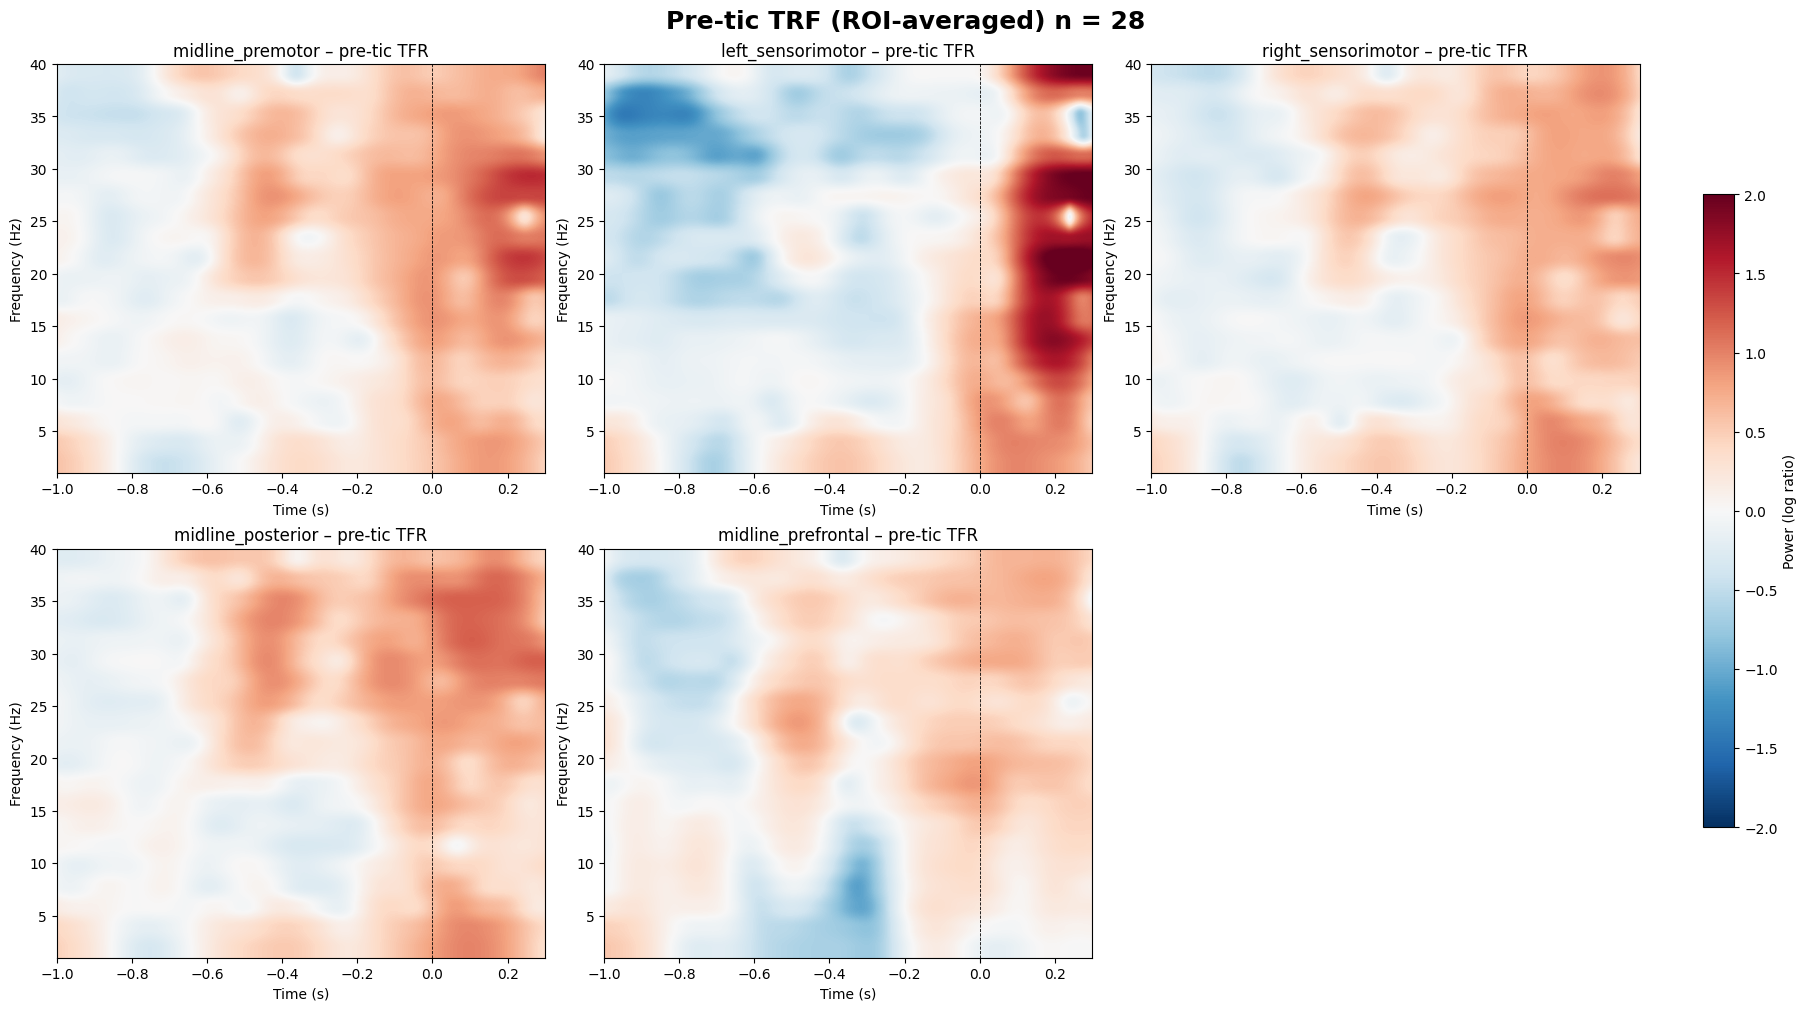

In [71]:

fig = plot_trf_roi(tfr_results_p2_spont, freqs_p2_spont, times_p2_spont, n_pre_tic, epoch_type='pre_tic')
plt.show()


## Spontaneous phase no-tic -- Patient 1

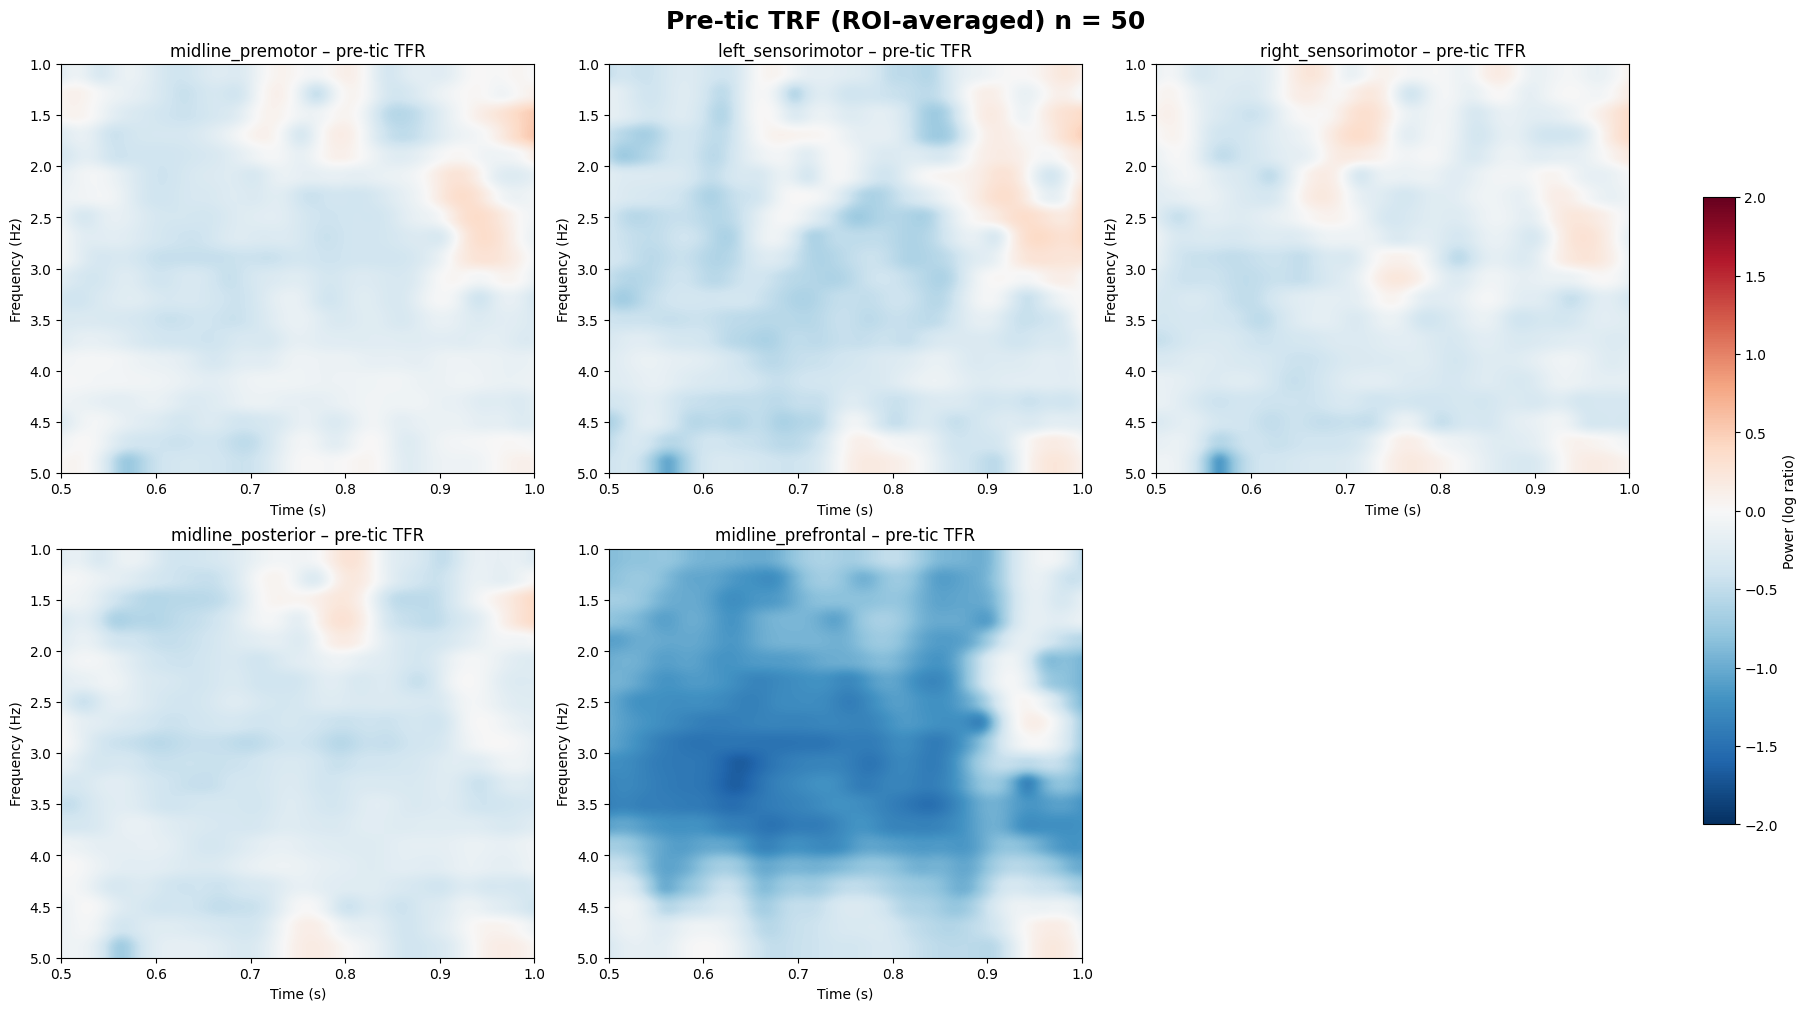

In [72]:
fig = plot_trf_roi(tfr_results_p2_spont_random, freqs_p2_spont_random, times_p2_spont_random, n_random, epoch_type='random')
plt.show()

## Analysis per frequency band 

This is done for each ROI and each participants seperately
Note: Data for patient 4 is incorrect 

In [69]:
theta = np.arange(4,7,1) # urge/cognitve control
alpha = np.arange(8,13,1) # motor inhibition
beta = np.arange(13,30,1) # motor preparation
gamma = np.arange(30,41,1) # too close to the boundry, no meaningful results

frequency_bands = {
    "theta": theta,
    "alpha": alpha,
    "beta": beta,
    "gamma": gamma
}

root_dir = "TRF_results_all_patients"
os.makedirs(root_dir, exist_ok=True)

for pid, epochs_p in zip(patient_ids, epochs_spont_patients):
    print(f"\nProcessing patient {pid}")
    patient_dir = os.path.join(root_dir, pid)
    os.makedirs(patient_dir, exist_ok=True)

    for band_name, freqs in frequency_bands.items():
        
        roi_tfr_results, freqs_band, times_band, n_pre_tic = tfr_per_ROI(
            patients[patient_ids.index(pid)], 
            epochs_p, 
            epoch_type='pre_tic', 
            freqs=freqs
        )
        fig = plot_trf_roi(roi_tfr_results, freqs_band, times_band, n_pre_tic, epoch_type='pre_tic')
        fig.suptitle(f"TFR Pre-Tic Epochs - Patient {pid} Spontaneous Phase - {band_name.capitalize()} Band (n={n_pre_tic})" , fontsize=18, fontweight="bold")
        fig.savefig(os.path.join(patient_dir, f'TFR_Pre-Tic_Epochs_{pid}_Spontaneous_Phase_{band_name}_Band.png'))
        plt.close(fig)
    



Processing patient DS26
Applying baseline correction (mode: logratio)
['Cz', 'C3', 'C4', 'Pz', 'Fp1', 'Fp2']


[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.0s finished


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.0s finished


['Cz', 'C3', 'C4', 'Pz', 'Fp1', 'Fp2']
Applying baseline correction (mode: logratio)


...

['Cz', 'FCz', 'C3', 'FC3', 'CP3', 'C4', 'CP4', 'FC4', 'Pz', 'CPz', 'Fp1', 'Fp2', 'AF3', 'AFz', 'AF4']
Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.5s finished


['Cz', 'FCz', 'C3', 'FC3', 'CP3', 'C4', 'CP4', 'FC4', 'Pz', 'CPz', 'Fp1', 'Fp2', 'AF3', 'AFz', 'AF4']
Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.5s finished


['Cz', 'FCz', 'C3', 'FC3', 'CP3', 'C4', 'CP4', 'FC4', 'Pz', 'CPz', 'Fp1', 'Fp2', 'AF3', 'AFz', 'AF4']


## Topographic map



Processing patient DS26 for topomap


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    0.7s finished


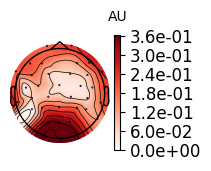


Processing patient BB28 for topomap


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.1s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    1.9s finished


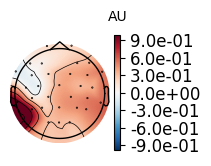


Processing patient BC29 for topomap


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.0s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    3.5s finished


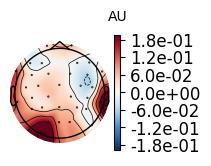


Processing patient MM30 for topomap


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    7.0s finished


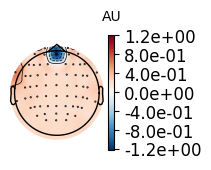


Processing patient SC31 for topomap


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    3.3s finished


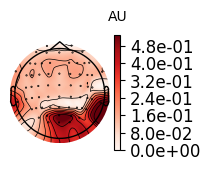

In [85]:
for pid, epochs_p in zip(patient_ids, epochs_spont_patients):
    print(f"\nProcessing patient {pid} for topomap")
    power = trf_analysis(epochs_p, epoch_type='pre_tic')
    fig = power.plot_topomap(fmin=1, fmax=40, tmin=-0.5, tmax=0.1, baseline=None, mode=None)


Processing patient DS26


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    0.6s finished


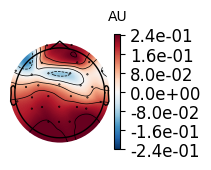

No baseline correction applied


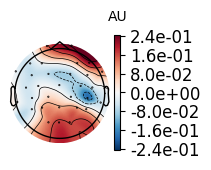

No baseline correction applied


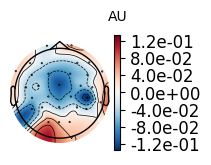

No baseline correction applied


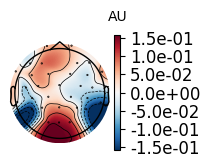


Processing patient BB28


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.1s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    2.0s finished


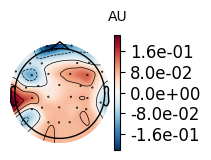

No baseline correction applied


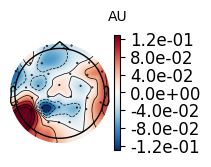

No baseline correction applied


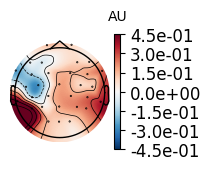

No baseline correction applied


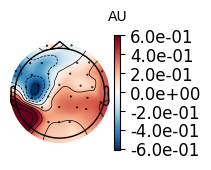


Processing patient BC29


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.4s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    4.0s finished


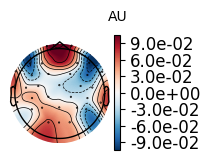

No baseline correction applied


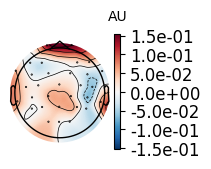

No baseline correction applied


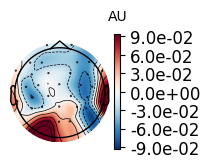

No baseline correction applied


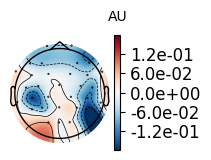


Processing patient MM30


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    6.9s finished


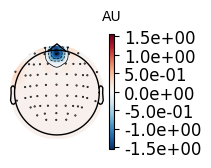

No baseline correction applied


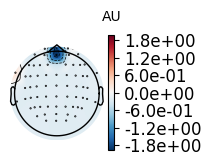

No baseline correction applied


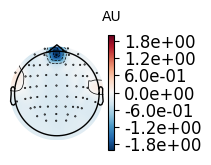

No baseline correction applied


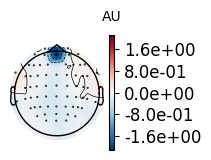


Processing patient SC31


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


Applying baseline correction (mode: logratio)
No baseline correction applied


[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    3.3s finished


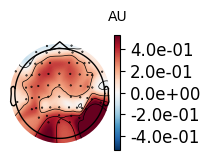

No baseline correction applied


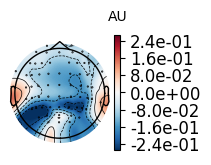

No baseline correction applied


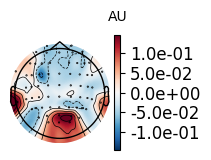

No baseline correction applied


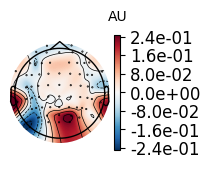

In [86]:
# for each patient 
root_dir = "TRF_topomap_results_ (freq bands)"
os.makedirs(root_dir, exist_ok=True)

for pid, epochs_p in zip(patient_ids, epochs_spont_patients):
    patient_dir = os.path.join(root_dir, pid)
    os.makedirs(patient_dir, exist_ok=True)
    print(f"\nProcessing patient {pid}")

    power = trf_analysis(epochs_p, epoch_type='pre_tic')

    for band_name, freqs in frequency_bands.items():
        f_min, f_max = freqs[0], freqs[-1]
        fig = power.plot_topomap(
            fmin=f_min, 
            fmax=f_max, 
            tmin=-1, 
            tmax=0, 
            mode=None, 
            baseline=None
        )
        fig.suptitle(f" {band_name.capitalize()} Band", fontsize=18, fontweight="bold")
        fig.savefig(os.path.join(patient_dir, f'TFR_Topomap_{pid}_Spontaneous_Phase_{band_name}_Band.png'))
        plt.close(fig)
        


### Loop over patients and phases 

In [13]:
import os
import re

def get_patient_id(patient):
    fname = os.path.basename(patient["vhdr"])
    match = re.search(r"\d+", fname)
    return match.group(0) if match else "unknown"


In [ ]:
import os

output_dir = "tfr_results"
os.makedirs(output_dir, exist_ok=True)
patient_ids = ["DS26", "BB28", "BC29", "MM30", "SC31"]

for patient, pid in zip(patients, patient_ids):

    pre_tic_epochs, random_epochs = full_pipeline_extract_pre_tic_epochs(
        patient,
        phase="spontaneous_phase",
        nb_random_epochs=50
    )

    # --- PRE-TIC ---
    tfr_pre, freqs_pre, times_pre, n_pre_tic = tfr_per_ROI(
        patient,
        pre_tic_epochs,
        epoch_type="pre_tic"
    )

    fig_pre = plot_trf_roi(
        tfr_pre,
        freqs_pre,
        times_pre,
        n_pre_tic
    )

    fig_pre.savefig(
        os.path.join(output_dir, f"patient_{pid}_pre_tic_TFR (n={n_pre_tic}).png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig_pre)

    # --- RANDOM ---
    tfr_rand, freqs_rand, times_rand, n_random = tfr_per_ROI(
        patient,
        random_epochs,
        epoch_type="random"
    )

    fig_rand = plot_trf_roi(
        tfr_rand,
        freqs_rand,
        times_rand,
        n_random
    )

    fig_rand.savefig(
        os.path.join(output_dir, f"patient_{pid}_random_TFR (n={n_random}).png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig_rand)


# Functions for Imitated phase extraction and Suppressed 

For now there is a function to extract the imitated tics. Further, we need to create the function to extract suppressed tics. Almost the same with different conditions for S and F. Later store tics seperately for real and imitated/suppressed tics 

In [ ]:
def analyse_merged_ttl_tics_imitated(merged_ttl_tics,
                                    phase_start_key='start_spont',
                                    phase_end_key='end_spont',
                                    max_t_after_end=1.0,
                                    max_t_after_F=2.0):
    """
    We devide tics into real and imitated. For real tics we check if the T occured. For imitated we check D and F keys if they occured. 
    For T occuring without any tic around it (from excel) we disregard the T (treating it as an error)---- might add later 
    """

    t_start = next((list(d.values())[0] for d in merged_ttl_tics
                    if list(d.keys())[0] == phase_start_key), None)
    t_end   = next((list(d.values())[0] for d in merged_ttl_tics
                    if list(d.keys())[0] == phase_end_key), None)

    phase_events = [d for d in merged_ttl_tics
                    if t_start < list(d.values())[0] < t_end]

    results_list = []
    i = 0

    while i < len(phase_events):

        key, value = next(iter(phase_events[i].items()))

        # ---------- Real tic -----------
        if key == 'T':

            found_back = None
            for j in range(i-1, -1, -1):
                k, v = next(iter(phase_events[j].items()))
                if k.startswith('start_'):
                    found_back = ('start_', v)
                    break
                elif k.startswith('end_i'):
                    found_back = ('end_i', v)
                    break
                elif k == 'D':
                    found_back = ('D', v)
                    break  
                elif k == 'F':
                    found_back = ('F', v)
                    break

            found_forward = None 
            for j_forward in range(i+1, len(phase_events)):
                k_fwd, v_fwd = next(iter(phase_events[j_forward].items()))
                if k_fwd == 'D':
                    found_forward = ('D', v_fwd)
                    break
                elif k_fwd == 'F':
                    found_forward = ('F', v_fwd)
                    break
                elif k_fwd.startswith('start_') or k_fwd.startswith('end_'):
                    break

            # Case 1 : T after start_i - T during real tic (excel)
            if found_back is not None and found_back[0] == 'start_i':
                results_list.append({
                    "type": "start_then_T",
                    "start_time": found_back[1]  
                })
                print(f"start_tic at {found_back[1]} then T pressed at {value}")
                print("Results list updated:", results_list)

            # Case 2 : T after end_i 
            elif found_back is not None and found_back[0] == 'end_i':
                time_after_end = value - found_back[1]
                if time_after_end <= max_t_after_end:
                    # find the start of the tic before end_i, backward search
                    start_found = None
                    for j in range(i-1, -1, -1):
                        key_k, value_k = next(iter(phase_events[j].items()))
                        if key_k.startswith('start_i'):
                            start_found = value_k
                            break
                    results_list.append({
                        "type": "end_then_T",
                        "start_time": start_found,
                    })
                    print(f"end_tic at {found_back[1]} then T pressed at {value}")
                    print("Results list updated:", results_list)
            
                # Case 3 : T before start_i 
                elif found_back is not None and found_back[0] == 'end_i':
                    if found_forward is not None and found_forward == 'start_i':
                        results_list.append({
                            "type": "T_before_start",
                            "T_time": value,
                        })
                        print(f"T pressed at {value} before tic starts at {found_forward[1]}")
                        print("Results list updated:", results_list)

            # Case 4 : T during the imitated tic (D before T)
            elif found_back is not None and found_back[0] == 'D':

                # Check if T comes after F (end of imitated tic)
                if found_forward is not None and found_forward[0] == 'F':
                    results_list.append({
                        "type": "D_then_T_then_F",
                        "D_time": found_back[1],
                    })
                    print(f"D at {found_back[1]} then F at {found_forward[1]}  T during pressed at {value}")
                    print("Results list updated:", results_list)

                else:
                    # Just D then T, no F after
                    results_list.append({
                        "type": "D_then_T",
                        "D_time": found_back[1],
                    })
                    print(f"T pressed at {value} during imitated tic started at {found_back[1]}")
                    print("Results list updated:", results_list)

            # Case 5 : T after F (end of imitated tic)
            elif found_back is not None and found_back[0] == 'F':
                time_after_F = value - found_back[1]
                if time_after_F <= max_t_after_F:
                    # Find the D before this F
                    D_found = None
                    for j in range(i-1, -1, -1):
                        key_k, value_k = next(iter(phase_events[j].items()))
                        if key_k == 'D':
                            D_found = value_k
                            break  
                        
                    results_list.append({
                        "type": "F_then_T",
                        "D_time": D_found,  
                    })
                    print(f"F at {found_back[1]} then T pressed at {value} (close after imitated tic)")
                    print("Results list updated:", results_list)

                elif found_back is not None and found_back[0] == 'F':
                    if found_forward is not None and found_forward[0] == 'D':
                        results_list.append({
                            "type": "T_before_D",
                            "T_time": value,
                        })
                        print(f"T pressed at {value} before D at {found_forward[1]}")
                        print("Results list updated:", results_list)
   
        # ----------- Imitated tic -----------
        if key == 'D':

            found_back = None
            for j in range(i-1, -1, -1):
                k, v = next(iter(phase_events[j].items()))
                if k.startswith('start_i'):
                    found_back = ('start_i', v)
                    break
                elif k.startswith('end_i'):
                    found_back = ('end_i', v)
                    break
                elif k =='D':
                    found_back = ('D', v)
                    break
            
            found_forward = None
            for j_forward in range(i+1, len(phase_events)):
                k_fwd, v_fwd = next(iter(phase_events[j_forward].items()))
                if k_fwd.startswith('start_'):
                    found_forward = ('start_i', v_fwd)
                    break
                elif k_fwd == 'F':
                    found_forward = ('F', v_fwd)
                    break
                elif k_fwd == 'T':
                    break
                elif k_fwd == 'D':
                    break

            # Case 1: D after start_i 
            if found_back is not None and found_back[0] == 'start_i':
                    results_list.append({
                        "type": "start_then_D",
                        "start_time": found_back[1],
                    })
                    print(f"start_tic at {found_back[1]} then D pressed at {value}")
                    print("Results list updated:", results_list)
                
            # Case 2 : D after D
            if found_back is not None and found_back[0] == 'D':
                # Look forward to see if there's start_i or just F
                found_forward = None
                for j_forward in range(i+1, len(phase_events)):
                    k_fwd, v_fwd = next(iter(phase_events[j_forward].items()))
                    if k_fwd.startswith('start_'):
                        found_forward = ('start_i', v_fwd)
                        break
                    elif k_fwd == 'F':
                        found_forward = ('F', v_fwd)
                        break
                    elif k_fwd == 'T' or k_fwd == 'D':
                        break
                
                # Exclude T in between the imitated tic 
                if found_forward is not None and found_forward[0] == 'T':
                    i += 1
                    continue

                # Only add D_then_F if there's F but NO start_i
                elif found_forward is not None and found_forward[0] == 'F':    
                
                        results_list.append({
                            "type": "D_then_F",
                            "D_time": value,
                        })
                        print(f"D at {value} then F pressed at {found_forward[1]} (no visible tic)")
                        print("Results list updated:", results_list)
                else: 
                    results_list.append({
                        "type": "D_then_D",
                        "D_time": value,  
                    })
                    print(f"D pressed at {value}")
                    print("Results list updated:", results_list)


            # Case 3: D after end_i 
            elif found_back is not None and found_back[0] == 'end_i':
                found_forward = None
                for j_forward in range(i+1, len(phase_events)):
                    k_fwd, v_fwd = next(iter(phase_events[j_forward].items()))
                    if k_fwd.startswith('start_'):
                        found_forward = ('start_i', v_fwd)
                        break
                    elif k_fwd == 'F':
                        found_forward = ('F', v_fwd)
                        break
                    elif k_fwd == 'T' or k_fwd == 'D':
                        break

                # D before start_i 
                if found_forward is not None and found_forward[0] == 'start_i':
                        results_list.append({
                            "type": "D_then_start",
                            "D_time": value,
                        })
                        print(f"D pressed at {value} then tic starts at {found_forward[1]}")
                        print("Results list updated:", results_list)
    

        i += 1

    # Filter out D_then_F entries where D was used in D_then_F_then_T
    F_then_T_D_times = {
        res["D_time"]
        for res in results_list
        if res["type"] == "F_then_T" and res.get("D_time") is not None
    }

    new_results = []
    upgraded_D_times = set()

    for res in results_list:
        if res["type"] == "D_then_F" and res["D_time"] in F_then_T_D_times:
            new_results.append({
                "type": "D_then_F_then_T",
                "D_time": res["D_time"]
            })
            upgraded_D_times.add(res["D_time"])

        elif res["type"] == "F_then_T" and res["D_time"] in upgraded_D_times:
            continue

        else:
            new_results.append(res)

    results_list = new_results
    print ("Final Results List:", results_list)



    return results_list

In [ ]:
analyse_merged_ttl_tics_imitated(merged_ttl_tics,
                                    phase_start_key='start_spont',
                                    phase_end_key='end_spont')

In [ ]:
def full_pipeline_extract_pre_tic_epochs(patient, phase,nb_random_epochs):
    # Run the full pipeline for the patient
    results = run_full_pipeline_for_patient(
        vhdr_path = patient["vhdr"],
        excel_path = patient["excel"],
        fps = patient["fps"],
        min_absence_frames = patient["min_absence_frames"],
        montage_name = patient["montage"],
        excel_phase_times = patient["excel_phase_times"],
        )
    print("Results merged ttl tics:", results["merged_ttl_tics"])

        
    phase_map = {
        "spontaneous_phase": ("start_spont", "end_spont"),
        "imitated_phase": ("start_imit", "end_imit"),
        "suppressed_phase": ("start_ret", "end_ret"),
        }
    filter_dict = {
        'D': 21, 
        'F': 22,
        'S': 23,
        'T': 24,
        'right': 25,
        'start_spont': 9,
        'end_spont': 10,
        'start_imit': 11,
        'end_imit': 12,
        'start_ret': 13,
        'end_ret': 14
        }
    phase_start_key, phase_end_key = phase_map[phase]

    #set the phase boundary 
    start_ttl_number = filter_dict[phase_start_key]
    end_ttl_number   = filter_dict[phase_end_key]

  
    ttl_info = results["ttl"]  

    start_time = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == start_ttl_number)
    end_time   = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == end_ttl_number)


    # Urges list 
    urges_list = {}
    analysis_list_patient = analyse_merged_ttl_tics_imitated(
        merged_ttl_tics=results["merged_ttl_tics"],
        phase_start_key = phase_start_key, 
        phase_end_key = phase_end_key,
        )
    urges_list[f"list_urges_{results['subject']}"] = analysis_list_patient

    # Shift urges to EEG time
    urges_list = urges_list[f"list_urges_{results['subject']}"]
    stim2_time = results["stim2_time_original"]

    urges_times_EEG_patient = shift_urges_times(
        urges_list=urges_list,
        stim2_time=stim2_time,
        )

    # Extract pre-tic epochs
    pre_tic_epochs = extract_pre_tic_epochs(
        raw_cropped =results["raw_cropped"],
        urge_times =urges_times_EEG_patient,
        pre_seconds=2.0, post_seconds=0.5
        )
    print("Pre-tic epochs extracted:", pre_tic_epochs)

    # Extract random epochs in the same phase
    random_epochs = extract_random_epochs_in_phase(
        raw_cropped=results["raw_cropped"],
        start_time=start_time,
        end_time=end_time,
        n_epochs=nb_random_epochs,
        epoch_duration=2.5,
        event_id=999,
        seed=42
        )
    
    return pre_tic_epochs, random_epochs

In [ ]:
pre_tic_epochs_im, random_epochs_im = full_pipeline_extract_pre_tic_epochs(patients[0], phase="imitated_phase", nb_random_epochs=50)